# Ejercicios: comparación de modelos de regresión con distintas extracciones

**Materia:** Tópicos de Big Data
**Tema:** Regresión lineal, regresión polinomial y Random Forest
**Basado en:** la práctica `U3_1_modelos_regresion_demografia.ipynb`

---

## Objetivo

Repetir el ejercicio de los tres modelos (RL, RP y RF) sobre tres extracciones distintas
del mismo dataset de nacimientos y defunciones de OWID, y comparar cómo cambian las
proyecciones:

1. **Ejercicio 1:** China, con toda su historia disponible (1950-2023).
2. **Ejercicio 2:** México, entrenando solo con datos **a partir de 1980**.
3. **Ejercicio 3:** México, entrenando solo con datos **a partir de 2000**.

En los tres casos se proyecta hasta el año 2100 y se compara contra la proyección
oficial de OWID (escenario medio de la ONU).

La pregunta de fondo es: **¿qué tanto cambia la predicción si cambiamos el periodo con
el que entrenamos al modelo, usando exactamente los mismos modelos y el mismo dataset?**


# PARTE 1. Importar las bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

# PARTE 2. Cargar y preparar el dataset

Se usa el mismo dataset de la práctica original. Igual que antes, unificamos las
columnas de datos históricos (`..._estimates`) y de proyección de OWID
(`..._projected`) en dos columnas: `births` y `deaths`.


In [2]:
url = "https://ourworldindata.org/grapher/births-and-deaths-projected-to-2100.csv?v=1&csvType=full&useColumnShortNames=true"

df = pd.read_csv(
    url,
    storage_options={"User-Agent": "Our World In Data data fetch/1.0"}
)

df = df.rename(columns={
    "entity": "Entity",
    "code": "Code",
    "year": "Year",
    "births__sex_all__age_all__variant_estimates": "births_estimates",
    "births__sex_all__age_all__variant_medium__projected": "births_projected",
    "deaths__sex_all__age_all__variant_estimates": "deaths_estimates",
    "deaths__sex_all__age_all__variant_medium__projected": "deaths_projected",
})

# Dato histórico si existe; si no, la proyección de OWID
df["births"] = df["births_estimates"].fillna(df["births_projected"])
df["deaths"] = df["deaths_estimates"].fillna(df["deaths_projected"])

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (39562, 9)


,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN,383985.0,290972.0
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN,391002.0,288752.0
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN,397663.0,288059.0
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN,404666.0,287712.0
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN,410428.0,289189.0


# PARTE 3. Funciones reutilizables

Como vamos a repetir exactamente el mismo procedimiento tres veces (y dos veces dentro
de cada caso, una para nacimientos y otra para defunciones), conviene escribirlo una
sola vez en forma de funciones. Así evitamos copiar y pegar las mismas celdas seis
veces, y nos aseguramos de que los tres ejercicios se resuelvan de forma idéntica.

Las funciones son:

| Función | Qué hace |
|---|---|
| `preparar` | Separa los datos de un país en histórico (entrenamiento) y proyección de OWID |
| `ajustar_modelos` | Entrena los tres modelos y devuelve sus proyecciones hasta 2100 |
| `graficar` | Dibuja los datos históricos, la proyección de OWID y las tres predicciones |
| `tabla_resumen` | Muestra en números lo que predice cada modelo en años seleccionados |


In [3]:
ANIO_CORTE = 2023
ANIOS_FUTUROS = pd.DataFrame(np.arange(2024, 2101), columns=["Year"])


def preparar(pais, desde=1950):
    """Devuelve (historico, proyectado) para un pais, entrenando desde el anio indicado."""
    datos_pais = df[df["Entity"] == pais]

    historico = datos_pais[
        (datos_pais["Year"] >= desde) & (datos_pais["Year"] <= ANIO_CORTE)
    ]
    proyectado = datos_pais[datos_pais["Year"] > ANIO_CORTE]

    return historico, proyectado

In [4]:
def ajustar_modelos(historico, variable):
    """Entrena los 3 modelos con (Year -> variable) y proyecta hasta 2100."""
    X = historico[["Year"]]
    y = historico[variable]

    # Modelo 1: regresion lineal
    modelo_lineal = LinearRegression()
    modelo_lineal.fit(X, y)

    # Modelo 2: regresion polinomial de grado 2
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly.fit_transform(X)

    modelo_polinomial = LinearRegression()
    modelo_polinomial.fit(X_poly, y)

    # Modelo 3: Random Forest
    modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
    modelo_rf.fit(X, y)

    return {
        "anios": ANIOS_FUTUROS["Year"].to_numpy(),
        "lineal": modelo_lineal.predict(ANIOS_FUTUROS),
        "polinomial": modelo_polinomial.predict(poly.transform(ANIOS_FUTUROS)),
        "rf": modelo_rf.predict(ANIOS_FUTUROS),
        "pendiente": modelo_lineal.coef_[0],
    }

In [5]:
ETIQUETAS = {"births": "Nacimientos", "deaths": "Defunciones"}


def graficar(historico, proyectado, predicciones, variable, titulo, limite_y=None):
    """Grafica datos historicos, proyeccion de OWID y las 3 predicciones."""
    plt.figure(figsize=(13, 6))

    plt.scatter(
        historico["Year"], historico[variable],
        alpha=0.5, label="Datos históricos (entrenamiento)"
    )
    plt.plot(
        proyectado["Year"], proyectado[variable],
        color="black", linewidth=2.5, label="Proyección OWID"
    )
    plt.plot(
        predicciones["anios"], predicciones["lineal"],
        color="tab:orange", linestyle="--", label="Regresión lineal"
    )
    plt.plot(
        predicciones["anios"], predicciones["polinomial"],
        color="tab:green", linestyle="--", label="Regresión polinomial"
    )
    plt.plot(
        predicciones["anios"], predicciones["rf"],
        color="tab:red", linestyle="--", label="Random Forest"
    )

    plt.axvline(ANIO_CORTE, color="gray", linewidth=1, alpha=0.7)

    plt.title(titulo)
    plt.xlabel("Año")
    plt.ylabel(ETIQUETAS[variable])

    if limite_y is not None:
        plt.ylim(limite_y)

    plt.ticklabel_format(style="plain", axis="y", useOffset=False)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [6]:
ANIOS_TABLA = [2030, 2050, 2075, 2100]


def tabla_resumen(proyectado, predicciones, variable):
    """Compara en numeros lo que predice cada modelo contra OWID."""
    indice = predicciones["anios"]

    owid = (
        proyectado.set_index("Year")[variable]
        .reindex(indice)
        .to_numpy()
    )

    tabla = pd.DataFrame(
        {
            "OWID": owid,
            "Regresión lineal": predicciones["lineal"],
            "Regresión polinomial": predicciones["polinomial"],
            "Random Forest": predicciones["rf"],
        },
        index=indice,
    )
    tabla.index.name = "Año"

    return tabla.loc[ANIOS_TABLA].round(0)

---

# EJERCICIO 1. China (historia completa, 1950-2023)

Extraemos China y entrenamos los tres modelos con toda su historia disponible.


In [7]:
historico_china, proyectado_china = preparar("China", desde=1950)

print("Entrenamiento ->", historico_china.shape, "| años:",
      historico_china["Year"].min(), "a", historico_china["Year"].max())
print("Proyección OWID ->", proyectado_china.shape, "| años:",
      proyectado_china["Year"].min(), "a", proyectado_china["Year"].max())

historico_china[["Entity", "Year", "births", "deaths"]].head()

Entrenamiento -> (74, 9) | años: 1950 a 2023
Proyección OWID -> (77, 9) | años: 2024 a 2100


,Entity,Year,births,deaths
7097,China,1950,22293376.0,12564023.0
7098,China,1951,22144814.0,12411701.0
7099,China,1952,25496318.0,12459848.0
7100,China,1953,24139416.0,12309525.0
7101,China,1954,25438544.0,12145578.0


## 1.1 Nacimientos en China

Pendiente de la regresión lineal: -187,208.3 nacimientos por año


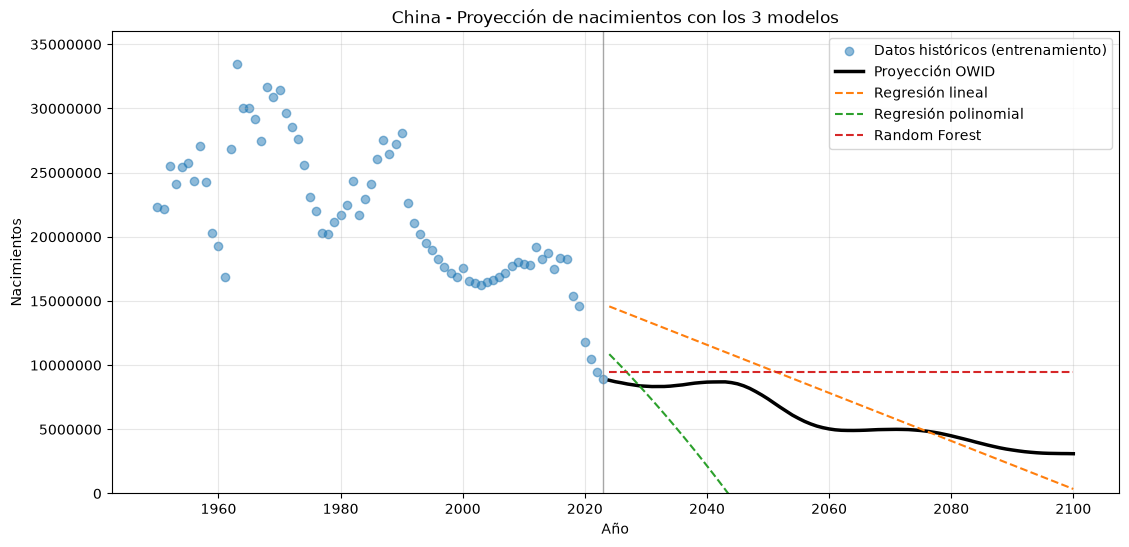

In [8]:
pred_china_births = ajustar_modelos(historico_china, "births")

print(f"Pendiente de la regresión lineal: {pred_china_births['pendiente']:,.1f} nacimientos por año")

graficar(
    historico_china, proyectado_china, pred_china_births,
    "births",
    "China - Proyección de nacimientos con los 3 modelos",
    limite_y=(0, 36_000_000),
)

In [9]:
tabla_resumen(proyectado_china, pred_china_births, "births")

,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,8359513.0,13456651.0,7830199.0,9489420.0
2050,7371348.0,9712484.0,-4298790.0,9489420.0
2075,4909046.0,5032277.0,-23867936.0,9489420.0
2100,3099844.0,352069.0,-48334758.0,9489420.0


## 1.2 Defunciones en China

Pendiente de la regresión lineal: -45,906.1 defunciones por año


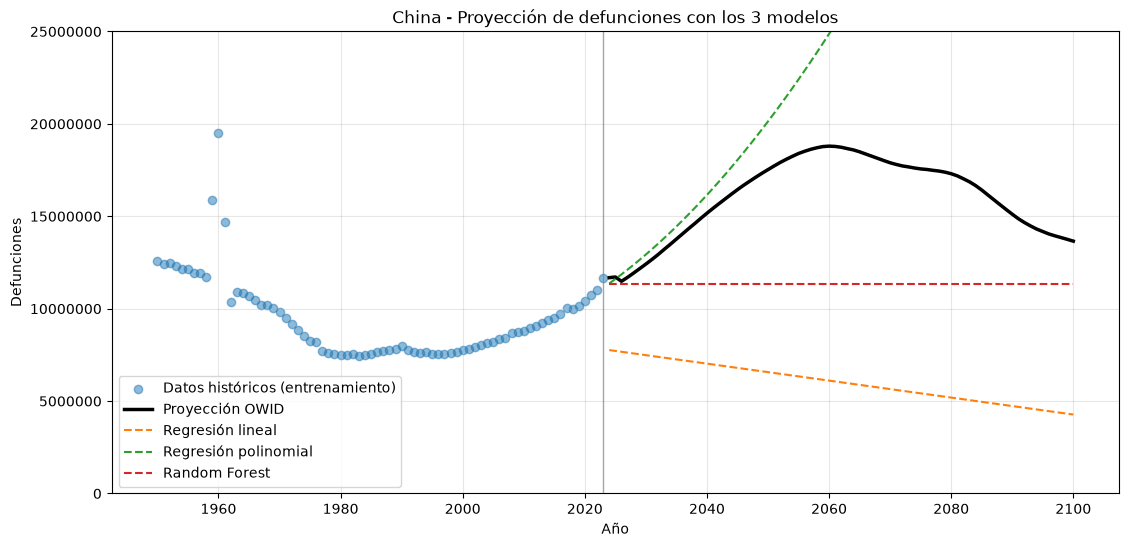

In [10]:
pred_china_deaths = ajustar_modelos(historico_china, "deaths")

print(f"Pendiente de la regresión lineal: {pred_china_deaths['pendiente']:,.1f} defunciones por año")

graficar(
    historico_china, proyectado_china, pred_china_deaths,
    "deaths",
    "China - Proyección de defunciones con los 3 modelos",
    limite_y=(0, 25_000_000),
)

In [11]:
tabla_resumen(proyectado_china, pred_china_deaths, "deaths")

,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,12415078.0,7485699.0,12933834.0,11339159.0
2050,17526300.0,6567577.0,20134799.0,11339159.0
2075,17564112.0,5419925.0,33404217.0,11339159.0
2100,13655445.0,4272272.0,51416093.0,11339159.0


### Interpretación del Ejercicio 1

**China arrastra dos eventos históricos enormes** que dominan el entrenamiento: la
hambruna del Gran Salto Adelante (1959-1961), con el pico de **19,506,192 defunciones en
1960** y una caída brutal de nacimientos, y el máximo de **33,461,050 nacimientos en
1963**. En 2023 los nacimientos ya habían bajado a 8,899,881.

**Nacimientos.** La pendiente de la regresión lineal es de **−187,208 por año**, así que
por primera vez la recta sí baja. Aun así proyecta 13,456,651 para 2030, muy por encima
de los 8,359,513 de OWID: la recta viene cayendo desde valores de los años sesenta que
ya no tienen nada que ver con la China actual. El polinomio se derrumba todavía más
rápido y se vuelve **negativo a partir de 2044**, terminando en −48,334,758 en 2100. El
Random Forest, como siempre, se congela en **9,489,420** para los 77 años.

**Defunciones.** Aquí aparece el error más grave de todo el ejercicio: la regresión
lineal aprende una pendiente **negativa** (−45,906 por año) y predice que las defunciones
en China van a **bajar** hasta 4,272,272 en 2100, cuando OWID proyecta 13,655,445 y en
ascenso. El modelo se equivoca en la dirección por culpa del pico de la hambruna de
1960: ese valor extremo al inicio de la serie jala la recta hacia abajo. El polinomio
acierta la dirección pero se dispara a 51,416,093, casi el triple de OWID.

**Conclusión del caso:** ningún modelo funciona bien cuando la serie contiene un evento
catastrófico al principio. Un solo dato atípico basta para invertir el signo de la
pendiente y hacer que el modelo prediga justo lo contrario de lo que va a pasar.


---

# EJERCICIO 2. México a partir de 1980

Mismo país que la práctica original, pero recortando el entrenamiento: en lugar de usar
desde 1950, usamos **solo de 1980 en adelante**. Con esto dejamos fuera la etapa de
crecimiento acelerado de los nacimientos.


In [12]:
historico_mx80, proyectado_mx80 = preparar("Mexico", desde=1980)

print("Entrenamiento ->", historico_mx80.shape, "| años:",
      historico_mx80["Year"].min(), "a", historico_mx80["Year"].max())

historico_mx80[["Entity", "Year", "births", "deaths"]].head()

Entrenamiento -> (44, 9) | años: 1980 a 2023


,Entity,Year,births,deaths
22831,Mexico,1980,2357249.0,464115.0
22832,Mexico,1981,2366047.0,461670.0
22833,Mexico,1982,2384613.0,462853.0
22834,Mexico,1983,2404958.0,465775.0
22835,Mexico,1984,2431036.0,470587.0


## 2.1 Nacimientos en México desde 1980

Pendiente de la regresión lineal: -8,434.0 nacimientos por año


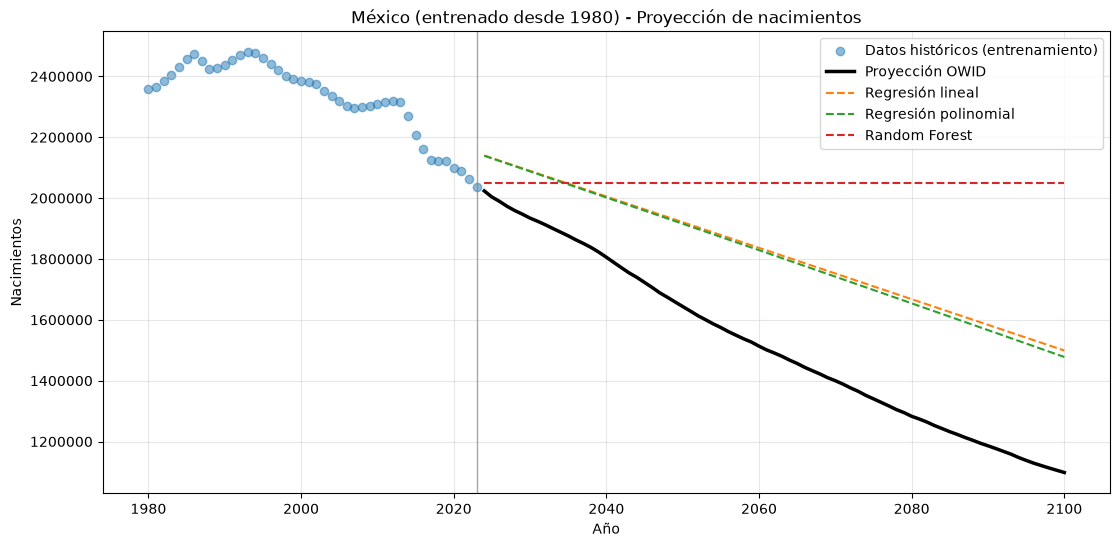

In [13]:
pred_mx80_births = ajustar_modelos(historico_mx80, "births")

print(f"Pendiente de la regresión lineal: {pred_mx80_births['pendiente']:,.1f} nacimientos por año")

graficar(
    historico_mx80, proyectado_mx80, pred_mx80_births,
    "births",
    "México (entrenado desde 1980) - Proyección de nacimientos",
)

In [14]:
tabla_resumen(proyectado_mx80, pred_mx80_births, "births")

,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,1934285.0,2089561.0,2087828.0,2049777.0
2050,1643767.0,1920880.0,1915645.0,2049777.0
2075,1340246.0,1710029.0,1698043.0,2049777.0
2100,1098210.0,1499178.0,1477803.0,2049777.0


## 2.2 Defunciones en México desde 1980

Pendiente de la regresión lineal: 9,975.8 defunciones por año


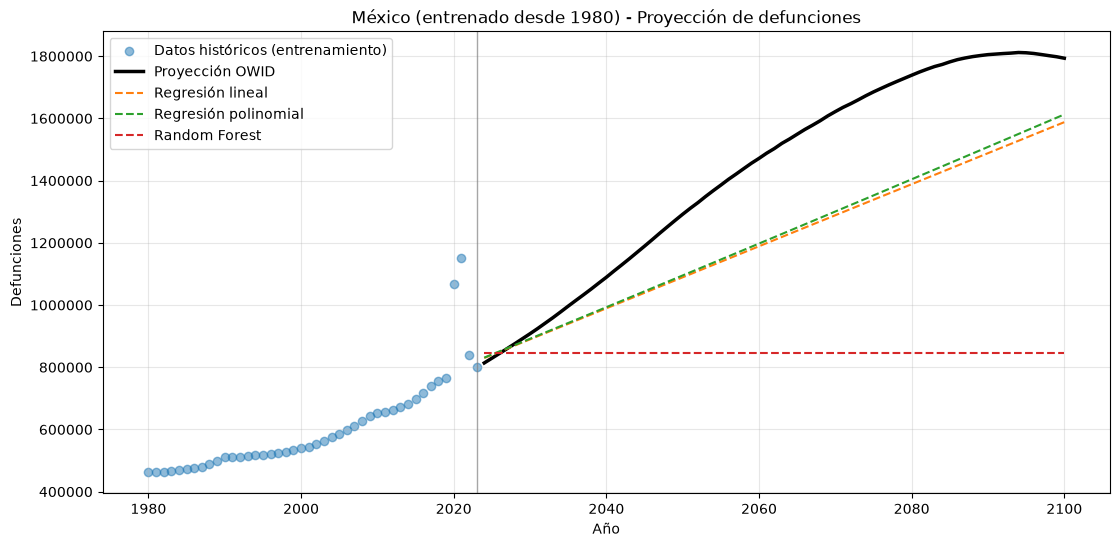

In [15]:
pred_mx80_deaths = ajustar_modelos(historico_mx80, "deaths")

print(f"Pendiente de la regresión lineal: {pred_mx80_deaths['pendiente']:,.1f} defunciones por año")

graficar(
    historico_mx80, proyectado_mx80, pred_mx80_deaths,
    "deaths",
    "México (entrenado desde 1980) - Proyección de defunciones",
)

In [16]:
tabla_resumen(proyectado_mx80, pred_mx80_deaths, "deaths")

,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,907843.0,889656.0,891581.0,845495.0
2050,1291889.0,1089172.0,1095151.0,845495.0
2075,1685181.0,1338568.0,1352420.0,845495.0
2100,1793462.0,1587964.0,1612808.0,845495.0


### Interpretación del Ejercicio 2

**Recortar el periodo de entrenamiento arregla el problema principal de la práctica
original.** Con toda la historia (1950-2023) la regresión lineal aprendía una pendiente
de **+8,511** nacimientos por año y proyectaba que México llegaría a 3,139,315
nacimientos en 2100. Entrenando solo desde 1980, la pendiente se vuelve **−8,434** por
año y el modelo proyecta **1,499,178 en 2100**, ahora sí en la dirección correcta y en el
mismo orden de magnitud que los 1,098,210 de OWID.

**El polinomio deja de explotar.** En la práctica original predecía nacimientos negativos
a partir de 2058; aquí termina en 1,477,803, prácticamente igual que la recta. La razón
es que entre 1980 y 2023 la serie es casi una línea recta, así que el término cuadrático
queda muy pequeño y la parábola apenas se curva.

**Las defunciones salen bastante bien.** La pendiente es de +9,976 por año y la
proyección para 2100 es de 1,587,964, contra 1,793,462 de OWID. Se queda corta, pero
acierta la tendencia creciente.

**El Random Forest no mejora en absoluto.** Sigue devolviendo un único valor constante
(2,049,777 nacimientos y 845,495 defunciones) para los 77 años. Cambiar la ventana de
entrenamiento no le sirve de nada, porque su limitación no es qué datos ve, sino que
por construcción no puede extrapolar.


---

# EJERCICIO 3. México a partir de 2000

Recortamos todavía más: entrenamos únicamente con los datos **de 2000 en adelante**,
es decir, solo 24 años de historia.


In [17]:
historico_mx00, proyectado_mx00 = preparar("Mexico", desde=2000)

print("Entrenamiento ->", historico_mx00.shape, "| años:",
      historico_mx00["Year"].min(), "a", historico_mx00["Year"].max())

historico_mx00[["Entity", "Year", "births", "deaths"]].head()

Entrenamiento -> (24, 9) | años: 2000 a 2023


,Entity,Year,births,deaths
22851,Mexico,2000,2385977.0,540567.0
22852,Mexico,2001,2380261.0,543803.0
22853,Mexico,2002,2374140.0,553391.0
22854,Mexico,2003,2351177.0,563140.0
22855,Mexico,2004,2335226.0,575925.0


## 3.1 Nacimientos en México desde 2000

Pendiente de la regresión lineal: -14,819.7 nacimientos por año


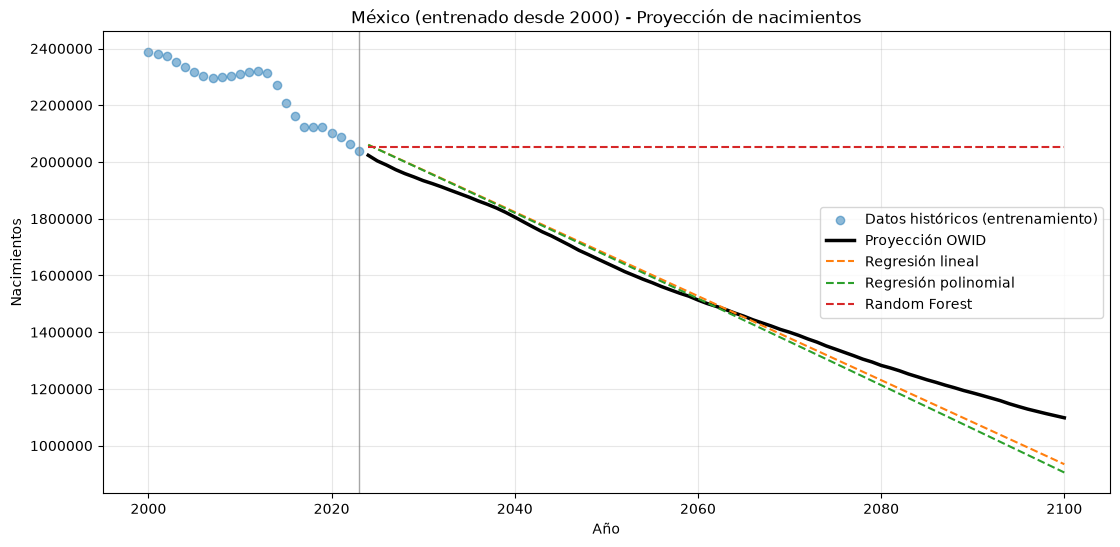

In [18]:
pred_mx00_births = ajustar_modelos(historico_mx00, "births")

print(f"Pendiente de la regresión lineal: {pred_mx00_births['pendiente']:,.1f} nacimientos por año")

graficar(
    historico_mx00, proyectado_mx00, pred_mx00_births,
    "births",
    "México (entrenado desde 2000) - Proyección de nacimientos",
)

In [19]:
tabla_resumen(proyectado_mx00, pred_mx00_births, "births")

,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,1934285.0,1971876.0,1970689.0,2051955.0
2050,1643767.0,1675481.0,1669982.0,2051955.0
2075,1340246.0,1304988.0,1289953.0,2051955.0
2100,1098210.0,934494.0,905317.0,2051955.0


## 3.2 Defunciones en México desde 2000

Pendiente de la regresión lineal: 17,578.8 defunciones por año


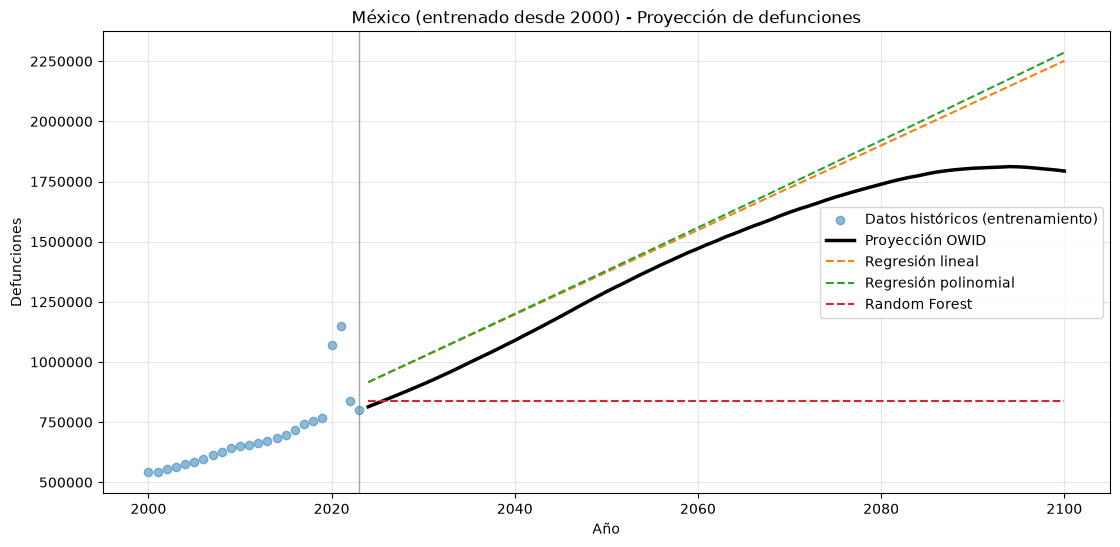

In [20]:
pred_mx00_deaths = ajustar_modelos(historico_mx00, "deaths")

print(f"Pendiente de la regresión lineal: {pred_mx00_deaths['pendiente']:,.1f} defunciones por año")

graficar(
    historico_mx00, proyectado_mx00, pred_mx00_deaths,
    "deaths",
    "México (entrenado desde 2000) - Proyección de defunciones",
)

In [21]:
tabla_resumen(proyectado_mx00, pred_mx00_deaths, "deaths")

,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,907843.0,1021129.0,1022528.0,838793.0
2050,1291889.0,1372705.0,1379209.0,838793.0
2075,1685181.0,1812175.0,1829978.0,838793.0
2100,1793462.0,2251646.0,2286211.0,838793.0


### Interpretación del Ejercicio 3

**En nacimientos, esta es la mejor proyección de todo el trabajo.** Con 24 años de
entrenamiento la pendiente es de **−14,820** por año y el modelo predice **1,971,876 para
2030**, contra 1,934,285 de OWID: una diferencia de menos del 2%. A largo plazo se separa
(934,494 contra 1,098,210 en 2100), pero mantiene la forma correcta durante todo el
periodo.

**En defunciones se pasa de largo.** La pendiente sube a +17,579 por año, más del doble
que en el Ejercicio 2, y la proyección para 2100 llega a **2,251,646** contra 1,793,462 de
OWID. El motivo es que la ventana 2000-2023 incluye el pico de COVID-19 de 2021
(1,150,760 defunciones) muy cerca del final de la serie. En una muestra de solo 24 años,
ese valor atípico pesa mucho más que en una de 74 y empuja la recta hacia arriba.

**Aparece entonces el compromiso central del ejercicio:** una ventana corta se adapta
mejor al comportamiento reciente, pero también queda más expuesta a que un solo evento
extraordinario distorsione el resultado. No existe una ventana "correcta" universal:
depende de si el fenómeno cambió de régimen y de qué tan limpios estén los últimos años.

**El Random Forest sigue exactamente igual:** 2,051,955 nacimientos y 838,793 defunciones
constantes hasta 2100.


---

# PARTE 4. Comparación final de las tres ventanas de entrenamiento

Para ver de golpe el efecto de la ventana, ponemos en una sola gráfica las proyecciones
de nacimientos de México entrenando desde 1950 (la práctica original), desde 1980 y
desde 2000.


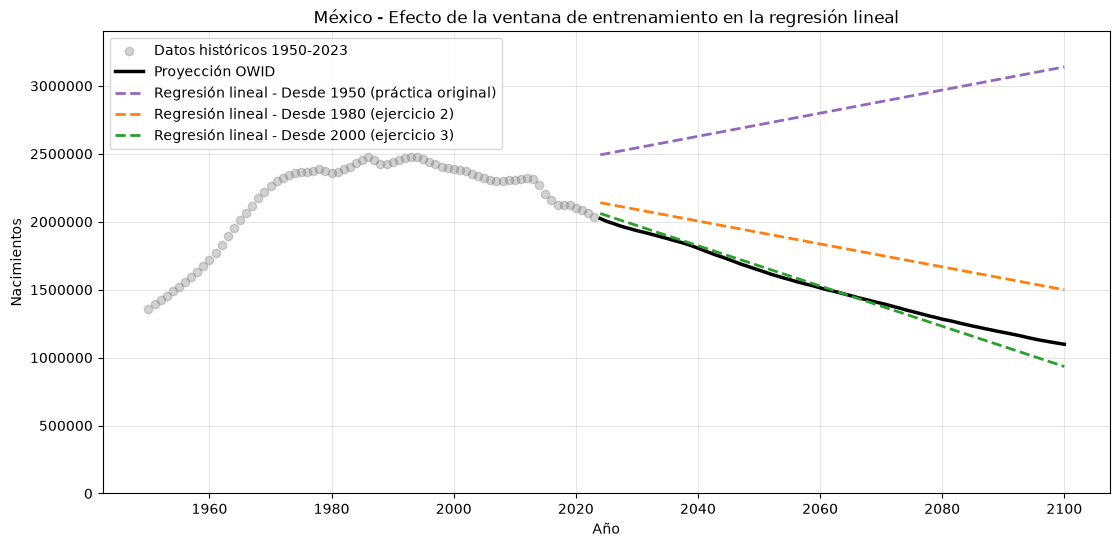

In [22]:
ventanas = {
    "Desde 1950 (práctica original)": ("tab:purple", 1950),
    "Desde 1980 (ejercicio 2)": ("tab:orange", 1980),
    "Desde 2000 (ejercicio 3)": ("tab:green", 2000),
}

resumen_pendientes = []

plt.figure(figsize=(13, 6))

historico_completo, proyectado_mx = preparar("Mexico", desde=1950)

plt.scatter(
    historico_completo["Year"], historico_completo["births"],
    alpha=0.35, color="gray", label="Datos históricos 1950-2023"
)
plt.plot(
    proyectado_mx["Year"], proyectado_mx["births"],
    color="black", linewidth=2.5, label="Proyección OWID"
)

for nombre, (color, desde) in ventanas.items():
    hist, _ = preparar("Mexico", desde=desde)
    pred = ajustar_modelos(hist, "births")

    plt.plot(
        pred["anios"], pred["lineal"],
        color=color, linestyle="--", linewidth=2,
        label=f"Regresión lineal - {nombre}"
    )

    resumen_pendientes.append({
        "Ventana": nombre,
        "Años de entrenamiento": len(hist),
        "Pendiente (nac./año)": round(pred["pendiente"], 1),
        "Predicción 2100": round(pred["lineal"][-1]),
    })

plt.title("México - Efecto de la ventana de entrenamiento en la regresión lineal")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ylim(0, 3_400_000)
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [23]:
comparacion = pd.DataFrame(resumen_pendientes)
comparacion["OWID 2100"] = int(
    proyectado_mx.loc[proyectado_mx["Year"] == 2100, "births"].iloc[0]
)
comparacion

,Ventana,Años de entrenamiento,Pendiente (nac./año),Predicción 2100,OWID 2100
0,Desde 1950 (práctica original),74,8510.8,3139315,1098210
1,Desde 1980 (ejercicio 2),44,-8434.0,1499178,1098210
2,Desde 2000 (ejercicio 3),24,-14819.7,934494,1098210


### Conclusión general

Los tres ejercicios usan **el mismo dataset y exactamente los mismos tres modelos**. Lo
único que cambió fue qué tramo de la historia se usó para entrenar, y aun así los
resultados son radicalmente distintos.

**1. La ventana de entrenamiento puede invertir la conclusión.** Para los nacimientos de
México, entrenar desde 1950 da una pendiente de **+8,511** por año (crecimiento) y
entrenar desde 1980 da **−8,434** (descenso). Mismos datos, mismo modelo, conclusiones
opuestas. La causa es que México cambió de régimen demográfico en 1993: incluir la etapa
previa contamina el ajuste con un comportamiento que ya no se repite.

**2. Los valores atípicos pesan más en ventanas cortas.** El pico de defunciones de 2021
por COVID-19 casi no afecta cuando se entrena con 74 años, pero en la ventana de 24 años
del Ejercicio 3 empuja la proyección de 2100 hasta 2,251,646, muy por encima de OWID. En
China ocurre lo mismo con la hambruna de 1960, que es tan extrema que le invierte el
signo a la pendiente de las defunciones.

**3. La regresión polinomial es la más sensible de las tres.** Con series largas y
curvas explota (nacimientos negativos en México desde 2058, en China desde 2044). Con
series cortas y casi rectas se comporta bien y prácticamente coincide con la recta.
Su grado de peligro depende por completo de los datos con que se entrene.

**4. El Random Forest es indiferente a todo esto.** En los tres ejercicios devolvió un
único valor constante para los 77 años proyectados. No importa qué ventana se use: los
árboles no extrapolan, y fuera del rango de entrenamiento repiten el último promedio que
conocen. Es el modelo que mejor ajusta el pasado y el que resulta inservible para
proyectar el futuro.

**Lo que hay que llevarse:** elegir el periodo de entrenamiento es una decisión tan
importante como elegir el modelo, y no es una decisión técnica sino de criterio sobre el
fenómeno. Hay que preguntarse si el pasado lejano sigue siendo representativo del
presente, y revisar si hay eventos extraordinarios que convenga tratar aparte.
